# Imports



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Stroming langs het schip (retourstroom, sinkage, draft)

Verband tussen retourstroom snelheid van het schip en de sinkage:

$$ v = - V_s + \sqrt{V_s^2 + 2 g \Delta h}$$


In [3]:
def vRet(Vs, dh):
    """Return the returnflow [m/s].
    
    Parameters
    ----------
    Vs: float
        Ship velocity
    dh: float
        Ship sinkage
    """
    g = 9.81
    return -Vs + np.sqrt(Vs ** 2 + 2 * g * dh) 

# Gegevens van enkele sheepspassages met een fraaie sinkage curve

De laatste 4 zijn een focus op M12 schepen.

Ik heb van alle schepen in het rapport van Femke er twaalf gekozen en de data uit de grafieken gehaald.

In [3]:
# Scheeps data uit de grafieken van het rapport van Femke (2025) met de resulaten van de metingen met het meetframe op de bodem van het ARK bij Nigtevegt (11-20 juni 2025.)
    
    # datetime         ship type, 'color', 'vs', 'vr', 'dh', 'draft', 'SNR', 'SNR0']
data = [        
    ['2025-07-11 14:15:26',  'M8', 'b', 4.0, 0.6011, -0.2223, 3.2, 43.6, 33.8],
    ['2025-07-11 14:35:55', 'M12', 'r', 3.7, 0.8339, -0.2721, 3.5, 49.4, 35.3],
    ['2025-07-11 15:13:54',  'M8', 'b', 4.4, 0.5945, -0.1864, 2.7, 44.2, 35.3],    
    ['2025-07-11 17:25:58',  'M8', 'b', 4.1, 0.6107, -0.2515, 2.8, 46.0, 32.3],
    ['2025-07-11 18:35:15',  'M9', 'g', 4.5, 0.4422, -0.1785, 2.7, 42.6, 33.0],
    ['2025-07-11 19:28:21', 'C31', 'b', 3.7, 0.5745, -0.2482, 3.7, 46.0, 33.2],
    ['2025-07-11 20:04:30',  'M8', 'b', 4.6, 0.4967, -0.2425, 2.0, 43.9, 31.8],
    ['2025-07-11 21:31:24',  'M8', 'b', 4.6, 0.6907, -0.2557, 2.9, 44.0, 33.5],
    ['2025-07-11 23:53:42',  'M8', 'b', 4.3, 0.4800, -0.2256, 2.7, 41.5, 32.9],    
    ['2025-07-12 02:08:50',  'M8', 'b', 3.3, 0.7311, -0.3055, 3.5, 47.0, 31.5],
    ['2025-07-12 02:58:27', 'M12', 'r', 3.3, 1.0677, -0.4246, 3.8, 49.5, 32.0],
    ['2025-07-12 03:29:32',  'M8', 'b', 4.9, 0.7291, -0.2940, 2.8, 47.4, 36.6],
    ['2025-07-12 03:37:37',  'M8', 'b', 3.9, 0.7804, -0.3054, 3.5, 47.0, 36.1],
    ['2025-07-12 12:03:42',  'M6', 'c', 4.1, 0.6240, -0.2813, 3.0, 43.4, 33.4],
    ['2025-07-13 13:14:16', 'M12', 'r', 3.3, 0.8828, -0.3190, 4.0, 48.0, 33.8],
    ['2025-07-13 16:23:06', 'M12', 'r', 3.5, 0.7388, -0.2364, 3.3, 48.5, 32.2],
    ['2025-07-13 18:07:19', 'M12', 'r', 3.2, 0.8274, -0.3453, 3.4, 47.8, 34.8],
    ['2025-07-13 21:15:57', 'M12', 'r', 3.4, 0.7903, -0.3350, 3.3, 47.5, 32.9],
]
ships = pd.DataFrame(data=data, columns=['datetime', 'type', 'color', 'vs', 'vr', 'dh', 'draft', 'SNR', 'SNR0'])
ships=ships.astype(dict(datetime='datetime64[ns]', vs=float, vr=float, dh=float, draft=float, SNR=float, SNR0=float))

ships['vr2'] = vRet(ships['vs'], -ships['dh'])
ships['dSNR'] = ships['SNR'] - ships['SNR0']

ships

,datetime,type,color,vs,vr,dh,draft,SNR,SNR0,vr2,dSNR
0,2025-07-11 14:15:26,M8,b,4.0,0.6011,-0.2223,3.2,43.6,33.8,0.512375,9.8
1,2025-07-11 14:35:55,M12,r,3.7,0.8339,-0.2721,3.5,49.4,35.3,0.662179,14.1
2,2025-07-11 15:13:54,M8,b,4.4,0.5945,-0.1864,2.7,44.2,35.3,0.397621,8.9
3,2025-07-11 17:25:58,M8,b,4.1,0.6107,-0.2515,2.8,46.0,32.3,0.563092,13.7
4,2025-07-11 18:35:15,M9,g,4.5,0.4422,-0.1785,2.7,42.6,33.0,0.373620,9.6
5,2025-07-11 19:28:21,C31,b,3.7,0.5745,-0.2482,3.7,46.0,33.2,0.608095,12.8
6,2025-07-11 20:04:30,M8,b,4.6,0.4967,-0.2425,2.0,43.9,31.8,0.490958,12.1
7,2025-07-11 21:31:24,M8,b,4.6,0.6907,-0.2557,2.9,44.0,33.5,0.516330,10.5
8,2025-07-11 23:53:42,M8,b,4.3,0.4800,-0.2256,2.7,41.5,32.9,0.487094,8.6
9,2025-07-12 02:08:50,M8,b,3.3,0.7311,-0.3055,3.5,47.0,31.5,0.809004,15.5


In [14]:
shipsM12 = pd.DataFrame(
    [['M12', 55, 4.0, 3.3,  0.8761, 0.2944],
     ['M12', 68, 4.0, 3.4,  1.3399, 0.5159],
     ['M12', 69, 4.0, 3.0,  0.5866, 0.2685],
     ['M12', 83, 4.0, 3.2,  0.9939, 0.3596],
     ['M12', 86, 3.9, 3.6,  0.5753, 0.2722],
     ['M12', 87, 3.9, 3.7,  0.7232, 0.3664],
     ['M12', 112, 3.9, 3.4, 0.6103, 0.3593]],
    columns = ['type', 'event', 'draft', 'vs', 'vr', 'dh'])

shipsM12['vr2'] = np.round(vRet(shipsM12['vs'], shipsM12['dh']), 2)
shipsM12['vr'] = np.round(shipsM12['vr'], 2)
shipsM12['dh'] = np.round(shipsM12['dh'], 2)
shipsM12 = shipsM12[['type', 'event', 'draft', 'dh', 'vs', 'vr', 'vr2']]

display(shipsM12)

speedy_ships = pd.DataFrame(
    [['M9', 17, 1.8, 5.1],
     ['M8', 38, 1.6, 5.0],
     ['M11', 40, 1.6, 5.0],
     ['M9', 50, 1.6, 5.3],
     ['M?', 56, 1.6, 5.0],
     ['M9', 74, 2.5, 5.1],
     ['M?', 77, 1.7, 5.4],
     ['M8', 80, 2.1, 5.3],
     ['M8', 88, 3.2, 5.0],
     ['M12', 89, 1.5, 5.0],
     ['M9', 97, 1.4, 5.2],
     ['M9', 98, 1.5, 5.3],
     ['BIIa-1', 104, 2.6, 5.5],
     ['M8', 105, 1.5, 5.1],
     ['M8', 113, 2.6, 5.0],
     ['M?', 120, 1.8, 5.0],
     ['M?', 145, 1.7, 5.0],
     ['M8', 155, 1.6, 5.3]],
    columns=['type', 'event', 'draft', 'vs']
)
display(speedy_ships)


,type,event,draft,dh,vs,vr,vr2
0,M12,55,4.0,0.29,3.3,0.88,0.78
1,M12,68,4.0,0.52,3.4,1.34,1.26
2,M12,69,4.0,0.27,3.0,0.59,0.78
3,M12,83,4.0,0.36,3.2,0.99,0.96
4,M12,86,3.9,0.27,3.6,0.58,0.68
5,M12,87,3.9,0.37,3.7,0.72,0.87
6,M12,112,3.9,0.36,3.4,0.61,0.91


,type,event,draft,vs
0,M9,17,1.8,5.1
1,M8,38,1.6,5.0
2,M11,40,1.6,5.0
3,M9,50,1.6,5.3
4,M?,56,1.6,5.0
5,M9,74,2.5,5.1
6,M?,77,1.7,5.4
7,M8,80,2.1,5.3
8,M8,88,3.2,5.0
9,M12,89,1.5,5.0


In [15]:
np.median(shipsM12['vs'])

np.float64(3.4)

# Berekende versus gemeten retourstroom [m/s]

De markers met grotere diepgang (draft) zijn groter gemaakt.

De schepen met de grooste diepgang (draft) liggen het mooist op de correlatielijn.

Text(0, 0.5, 'vr berekend [m/s]')

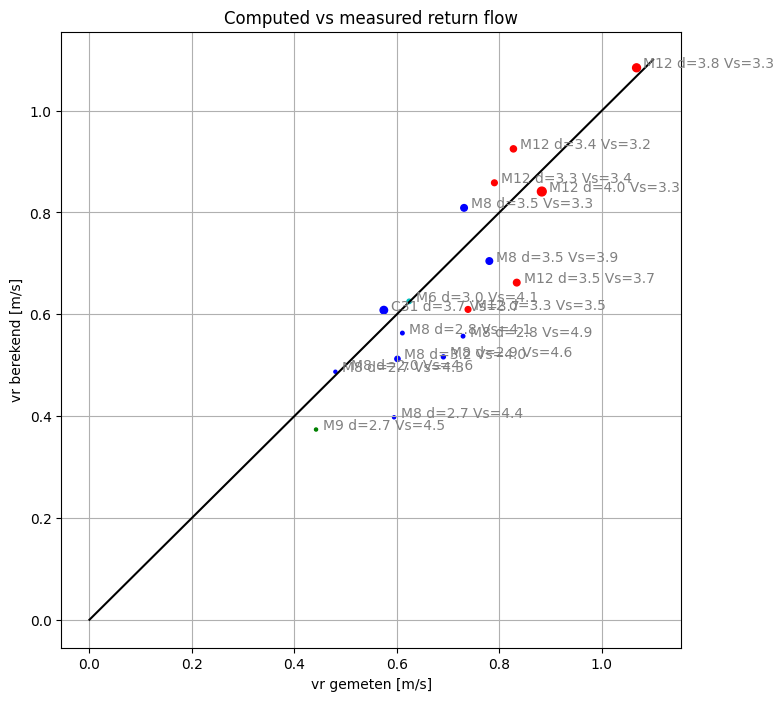

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))
# ax.scatter(ships['vr'], ships['vRet2'], s= (5 * ships['vs']) ** 2, c=ships['color'])
ax.scatter(ships['vr'], ships['vr2'], s= (10 * (ships['draft']-2.0) ** 2), c=ships['color'])

for i in ships.index:
    ship = ships.loc[i]
    plt.annotate(f"{ship['type']} d={ship['draft']:.1f} Vs={ship['vs']:.1f}",
                 (ship['vr'], ship['vr2']),
    textcoords="offset points",
    color='gray',
    xytext=(5, 0),
    ha='left'
    )
    

ax.plot([0., 1.1], [0., 1.1], 'k')
ax.grid(True)
ax.set_title("Computed vs measured return flow")
ax.set_xlabel('vr gemeten [m/s]')
ax.set_ylabel('vr berekend [m/s]')

# Toename SNR (signal to noise ratio) in db als functie van de berekende retourstroom

De verwachting is dat dit de grootste correlatie oplevert.

Toename SNR = piek SNR direct na passage minus SNR voor passage.


Text(0, 0.5, 'SNR - SNR0 [dB]')

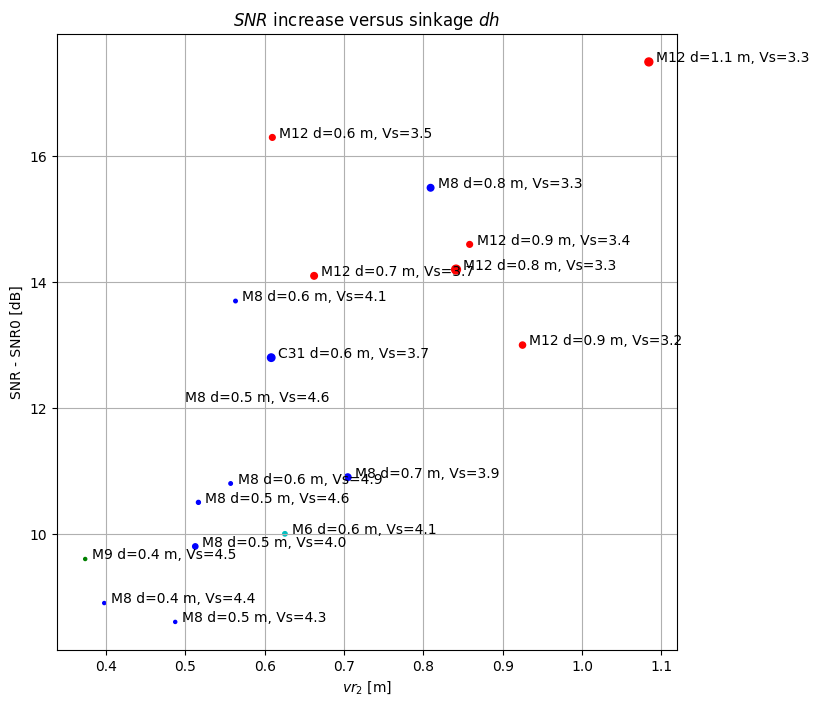

In [8]:
ships['vRet2'] = vRet(ships['vs'], -ships['dh'])
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(ships['vr2'], ships['SNR'] - ships['SNR0'], s= (10 * (ships['draft']-2.0) ** 2), c=ships['color'])

for i in ships.index:
    ship = ships.loc[i]
    plt.annotate(f"{ship['type']} d={ship['vr2']:.1f} m, Vs={ship['vs']:.1f}",
                 (ship['vr2'], ship['SNR'] - ship['SNR0']),
    textcoords="offset points",
    xytext=(5, 0),
    ha='left'
    )
    
ax.grid(True)
ax.set_title(r"$SNR$ increase versus sinkage $dh$")
ax.set_xlabel(r'$vr_2$ [m]')
ax.set_ylabel('SNR - SNR0 [dB]')

# Toename van SNR versus diepgang (draft)

Hoe groter de diepgang hoe meer opwoeling?

Text(0, 0.5, 'SNR - SNR0 [dB]')

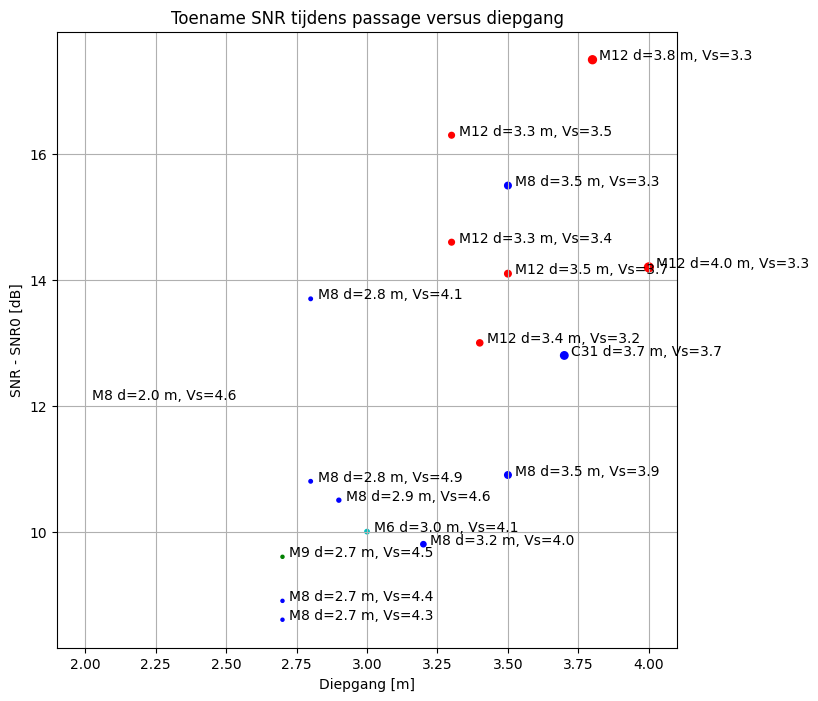

In [9]:
ships['vRet2'] = vRet(ships['vs'], -ships['dh'])
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(ships['draft'], ships['SNR'] - ships['SNR0'], s= (10 * (ships['draft']-2.0) ** 2), c=ships['color'])

for i in ships.index:
    ship = ships.loc[i]
    plt.annotate(f"{ship['type']} d={ship['draft']:.1f} m, Vs={ship['vs']:.1f}",
                 (ship['draft'], ship['SNR'] - ship['SNR0']),
    textcoords="offset points",
    xytext=(5, 0),
    ha='left'
    )
    
ax.grid(True)
ax.set_title("Toename SNR tijdens passage versus diepgang")
ax.set_xlabel('Diepgang [m]')
ax.set_ylabel('SNR - SNR0 [dB]')

# Correlatie tussen de verschillende variabelen van de scheepspassage

Correlatie vs x dSNR < 0 --> Hoe sneller het schip hoe minder opwerveling.
Maar vs x draft < 0 zegt feitelijk hoe minder diepgang des te sneller vaart het schip.

De dSNR heeft wel een sterke positieve relatie met de retourstroom. Retourstroom is ook schuifspanning op de bodem gezien het uniforme verticale snelheidsprofiel beneden de grenslaag. Dus het is de retourstroom die de opwerveling veroorzaakt.

Het enige relevante voor de opwerveling is de retourstroom. dh en vr zijn uiteraard zeer sterk gecorreleerd.

De correlatie tussen dSNR en de berekende retourstroom is zelfs nog groter dan tussen de dSNR en de gemeten retourstroom.

Ergo: de uit de vs en dh berekende retourstoom is een goede predictie voor de dSNR, de opwerveling.


In [10]:
ships[['vs', 'vr', 'vr2', 'dh', 'draft', 'dSNR']].corr()


,vs,vr,vr2,dh,draft,dSNR
vs,1.000000,-0.661810,-0.823581,0.618930,-0.819528,-0.747663
vr,-0.661810,1.000000,0.874961,-0.871829,0.740182,0.709009
vr2,-0.823581,0.874961,1.000000,-0.952791,0.733435,0.750627
dh,0.618930,-0.871829,-0.952791,1.000000,-0.604002,-0.653372
draft,-0.819528,0.740182,0.733435,-0.604002,1.000000,0.580600
dSNR,-0.747663,0.709009,0.750627,-0.653372,0.580600,1.000000


# Rapport Deltares 2012, Tabel 3.1

In [39]:
ship_props = pd.DataFrame([
    [110., 11.4, 3.5, 1700., 2.0, 700., 1.2],
    [135., 17.0, 4.0, 2800., 2.3, 1000., 1.4],
    ], index=['M8', 'M12'],
    columns=['L', 'b', 'd', 'MkW', 'MDp', 'BkW', 'BDp']
)
ship_props['A'] = ship_props['b'] * ship_props['d']

simulation = pd.DataFrame(
    [[518, 'M12', 3.75, 39.9, 'M0',  3.75,  0.0,  68.0, 7.6],
     [518, 'M8',  2.75, 68.0, 'M12', 3.75, 68.0, 107.9, 4.8],
     [518, 'M12', 2.25, 68.0, 'M12', 3.25, 68.0, 136.0, 3.8]
    ], index=[1, 2, 3], columns=['Ac', 'ship1', 'As1', 'vs1', 'ship2', 'vs2', 'As2', 'As1+As2', 'Ac/(As1+As2)']
)

display(ship_props)

display(simulation)

,L,b,d,MkW,MDp,BkW,BDp,A
M8,110.0,11.4,3.5,1700.0,2.0,700.0,1.2,39.9
M12,135.0,17.0,4.0,2800.0,2.3,1000.0,1.4,68.0


,Ac,ship1,As1,vs1,ship2,vs2,As2,As1+As2,Ac/(As1+As2)
1,518,M12,3.75,39.9,M0,3.75,0.0,68.0,7.6
2,518,M8,2.75,68.0,M12,3.75,68.0,107.9,4.8
3,518,M12,2.25,68.0,M12,3.25,68.0,136.0,3.8


In [40]:
def vR(rec, verbose=False):
    """Retourstroomsnelheid berekend als blokstroom.
    
    Parameters
    ----------
    rec: pd.DataFrame record
        record with simulation properties
    verbose: bool
        whether to show iteration progress computing vr
    """
    g = 9.81
    bc = 94.0 # --- Canal width
    vs1, vs2 = rec['vs1'], rec['vs2']
    As1, As2 = rec['As1'], rec['As2']
    Ac = rec['Ac']
    for i in range(10):
        vr = (vs1 * As1 + vs2 * As2) / (Ac - (As1 + As2))
        Ac = rec['Ac'] - bc * vr ** 2 / (2 * g)
        if verbose:
            print(f"{vr:5.3f} m/s, {vr**2/(2*g):4.2f} m")
    return vr

for idx in simulation.index:
    vr = vR(simulation.loc[idx], False)
    print(f"vr = {vr:.2f} m/s")

vr = 0.29 m/s
vr = 1.00 m/s
vr = 0.84 m/s
